# Phase 1: Machine Learning Classifiers from Scratch
Three classifiers (Logistic Regression, KNN, SVC) built from scratch with NumPy and evaluated on binary MNIST classification (digit 3 vs. rest).

## 0. Custom Classifiers
Logistic Regression, K-Nearest Neighbors, and Support Vector Classifier — implemented from scratch with NumPy only.

In [1]:
import numpy as np
from collections import Counter

# ═══════════════════════════════════════════════════════════════════════════════
#  Base
# ═══════════════════════════════════════════════════════════════════════════════

class _BaseClassifier:
    """Shared helpers for all classifiers."""

    def _encode_labels(self, y):
        """Map arbitrary labels to 0 … K-1 and store the mapping."""
        self.classes_ = np.unique(y) # Unique labels in sorted order
        self._label_to_idx = {c: i for i, c in enumerate(self.classes_)} # Map label to index, could be written as dict(zip(self.classes_, range(len(self.classes_))))
        return np.array([self._label_to_idx[v] for v in y]) # convert original labels to indices

    def _decode_labels(self, idx):
        return self.classes_[idx] # Reverse mapping from indices back to original labels

# ═══════════════════════════════════════════════════════════════════════════════
#  Logistic Regression (With Loss Tracking)
# ═══════════════════════════════════════════════════════════════════════════════

class LogisticRegression(_BaseClassifier):
    def __init__(self, lr=0.01, max_iter=1000, C=1.0, tol=1e-6, fit_intercept=True):
        self.lr = lr # Learning rate for gradient descent updates (Step size for updating weights)
        self.max_iter = max_iter # Maximum number of iterations for the optimization loop (Prevents infinite loops if convergence is slow)
        self.C = C # Inverse of regularization strength (L2 penalty term), smaller values specify stronger regularization
        self.tol = tol # Tolerance for convergence, if the change in loss is less than tol, we consider the optimization converged
        self.fit_intercept = fit_intercept # Whether to add an intercept term (bias) to the model, if True, a column of ones will be added to the input features

    @staticmethod
    def _sigmoid(z):
        pos = z >= 0 # For numerical stability, compute sigmoid differently for positive and negative z
        result = np.empty_like(z, dtype=float) # Allocate output array with the same size of z
        
        result[pos] = 1.0 / (1.0 + np.exp(-z[pos])) # For positive z, compute sigmoid directly

        exp_z = np.exp(z[~pos]) # For negative z, compute exp(z) first to avoid overflow in exp(-z)
        result[~pos] = exp_z / (1.0 + exp_z) # For negative z, compute sigmoid using exp(z) to maintain numerical stability
        
        return result

    def _add_intercept(self, X):
        if self.fit_intercept:
            return np.hstack([np.ones((X.shape[0], 1)), X]) # Add a column of ones to the left of X for the intercept term (Bias)
        return X

    def _fit_binary(self, X, y):
        n_samples, n_features = X.shape # Number of samples and features in the dataset (Rows and Columns of X)
        w = np.zeros(n_features) # Initialize weights to zero, including the intercept if fit_intercept is True
        reg = 1.0 / self.C # Regularization strength, inverse of C (L2 penalty term)
        prev_loss = np.inf # Initialize previous loss to infinity for convergence check

        loss_history = []

        for _ in range(self.max_iter):
            z = X @ w # Matrix Multiplication
            h = self._sigmoid(z) # Predicted probabilities for the positive class (Sigmoid of the linear combination of inputs and weights)

            # Calculate Cross-Entropy Loss + L2 Penalty
            eps = 1e-15 # Epsilon to prevent log(0) which can cause numerical issues
            loss = (-1 / n_samples) * (
                y @ np.log(h + eps) + (1 - y) @ np.log(1 - h + eps) # Core cross-entropy loss for binary classification
            ) + 0.5 * reg * np.dot(w, w) # L2 regularization term (0.5 * reg * ||w||^2)

            loss_history.append(loss) # Track loss for each iteration to analyze convergence

            grad = (1 / n_samples) * (X.T @ (h - y)) + reg * w # Gradient of the loss function with respect to weights (Includes both data loss and regularization gradient)
            # X.T -> Transpose of X, (h - y) --> Error between predicted probabilities and true labels, reg * w --> Gradient of the L2 regularization term

            w -= self.lr * grad # The Actual Learning, Updating the weights by moving in the direction of the negative gradient

            # Early stopping based on loss convergence
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        return w, loss_history

    # Multi class classification using one-vs-rest strategy
    def fit(self, X, y):
        
        X = np.asarray(X, dtype=float) # Convert input features to a NumPy array of type float for numerical computations
        y_enc = self._encode_labels(y) # Encode original labels to integer indices (0, 1, ..., K-1) and store the mapping for later decoding
        X = self._add_intercept(X) # Add intercept term to the input features if fit_intercept is True (Adds a column of ones to X)

        self.weights_ = [] # List to store the weights for each binary classifier (One-vs-rest approach, we will train K binary classifiers for K classes)
        self.loss_histories_ = [] # List to store the loss history for each binary classifier, useful for analyzing convergence and training dynamics

        for k in range(len(self.classes_)): # For each class k, we will train a binary classifier that distinguishes class k from all other classes (One-vs-rest strategy)
            binary_y = (y_enc == k).astype(float) # Create binary labels for the current class k, where samples of class k are labeled as 1 and all other samples are labeled as 0
            w, history = self._fit_binary(X, binary_y) # Fit a binary logistic regression model for class k using the _fit_binary method, which returns the weights and the loss history for this binary classification task

            self.weights_.append(w)
            self.loss_histories_.append(history)

        self.weights_ = np.array(self.weights_)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float) 
        X = self._add_intercept(X)
        logits = X @ self.weights_.T # Compute the linear combination of inputs and weights for each class (Logits), shape will be (n_samples, n_classes)
        probs = self._sigmoid(logits) # Apply sigmoid to logits to get predicted probabilities for each class, shape will be (n_samples, n_classes)
        probs /= probs.sum(axis=1, keepdims=True) # Normalize probabilities so that they sum to 1 for each sample (Softmax-like normalization for multi-class probabilities)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X) # Get predicted probabilities for each class
        return self._decode_labels(np.argmax(probs, axis=1)) # Predict the class with the highest probability for each sample and decode it back to original labels using the stored mapping


# ═══════════════════════════════════════════════════════════════════════════════
#  K-Nearest Neighbours Classifier
# ═══════════════════════════════════════════════════════════════════════════════

class KNeighborsClassifier(_BaseClassifier):
    def __init__(self, n_neighbors=5, p=2):
        self.n_neighbors = n_neighbors
        self.p = p

    def fit(self, X, y): # Store the training data and labels, and encode the labels to integer indices for easier processing during prediction
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        self._encode_labels(y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        predictions = []
        batch_size = 250  # Process 250 queries at a time to save memory

        for i in range(0, X.shape[0], batch_size):
            # Compute in batches, move the for loop in batches
            X_batch = X[i : i + batch_size] # Get a batch of queries to process, shape will be (batch_size, n_features)
            # Compute distance for the batch
            diff = X_batch[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :] # Broadcasting to compute pairwise differences between batch queries and training samples, shape will be (batch_size, n_train_samples, n_features)
            dists = np.sum(np.abs(diff) ** self.p, axis=2) ** (1.0 / self.p) # calculate the Lp distance between batch queries and training samples.
            nn_idx = np.argsort(dists, axis=1)[:, : self.n_neighbors] # get the indices of the k nearest neighbors for each query in the batch, shape will be (batch_size, n_neighbors)

            for neighbours in nn_idx:# loop over each query in the batch and its corresponding nearest neighbors
                labels = self.y_train_[neighbours] # Get the labels of the nearest neighbors for the current query, shape will be (n_neighbors,)
                
                counter = Counter(labels)
                predictions.append(counter.most_common(1)[0][0])
        
        return np.array(predictions)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float) 
        n_classes = len(self.classes_) # Number of unique classes in the training data, used to determine the number of columns in the probability output
        
        proba = np.zeros((X.shape[0], n_classes)) # Initialize an array to hold the predicted probabilities for each class, shape will be (n_samples, n_classes)
        batch_size = 250

        for i in range(0, X.shape[0], batch_size):
            X_batch = X[i : i + batch_size]


            # Calculating Distances in Batches
            diff = X_batch[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]
            dists = np.sum(np.abs(diff) ** self.p, axis=2) ** (1.0 / self.p)
            nn_idx = np.argsort(dists, axis=1)[:, : self.n_neighbors]

            # The Election of Neighbors and Probability Calculation
            for j, neighbours in enumerate(nn_idx):
                global_idx = i + j # Find the right row on the scoreboard for the current query in the batch
                
                labels = self.y_train_[neighbours]
                y_enc = np.array([self._label_to_idx[l] for l in labels])
                
                w = np.ones(len(neighbours))
                
                for cls_idx, weight in zip(y_enc, w):
                    proba[global_idx, cls_idx] += weight
                
                proba[global_idx] /= proba[global_idx].sum()
        return proba
# ═══════════════════════════════════════════════════════════════════════════════
#  Support Vector Classifier (With Convergence Tracking)
# ═══════════════════════════════════════════════════════════════════════════════

class SVC(_BaseClassifier):
    def __init__(self, tol=1e-3):
        self.C = 1.0 # Missclasification penalty
        # self.kernel = "rbf"
        self.tol = tol # KKT violations tolerance for convergence
        self.max_iter = 200 # max number of iterations for the optimization loop

    def _compute_kernel(self, X1, X2):
        sq1 = np.sum(X1 ** 2, axis=1).reshape(-1, 1)   # ||x||² for each row in X1, column vector
        sq2 = np.sum(X2 ** 2, axis=1).reshape(1, -1)   # ||x||² for each row in X2, row vector
        dist_sq = sq1 + sq2 - 2 * (X1 @ X2.T)          # ||x1 - x2||² via expansion trick
        return np.exp(-self._gamma * dist_sq)           # RBF: exp(-γ * ||x1-x2||²)
    
    def _fit_binary(self, X, y):
        n = X.shape[0]
        alpha = np.zeros(n)
        b = 0.0
        K = self._compute_kernel(X, X)
        convergence_history = []

        for _ in range(self.max_iter):
            changed = 0
            for i in range(n):
                Ei = (alpha * y) @ K[i] + b - y[i]
                if (y[i] * Ei < -self.tol and alpha[i] < self.C) or \
                   (y[i] * Ei > self.tol and alpha[i] > 0):
                    j = i
                    while j == i:
                        j = np.random.randint(0, n)
                    Ej = (alpha * y) @ K[j] + b - y[j]

                    ai_old, aj_old = alpha[i], alpha[j]

                    if y[i] != y[j]:
                        L = max(0, alpha[j] - alpha[i])
                        H = min(self.C, self.C + alpha[j] - alpha[i])
                    else:
                        L = max(0, alpha[i] + alpha[j] - self.C)
                        H = min(self.C, alpha[i] + alpha[j])
                    if L >= H:
                        continue

                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    alpha[j] -= y[j] * (Ei - Ej) / eta
                    alpha[j] = np.clip(alpha[j], L, H)
                    if abs(alpha[j] - aj_old) < 1e-8:
                        continue

                    alpha[i] += y[i] * y[j] * (aj_old - alpha[j])

                    b1 = b - Ei - y[i] * (alpha[i] - ai_old) * K[i, i] \
                         - y[j] * (alpha[j] - aj_old) * K[i, j]
                    b2 = b - Ej - y[i] * (alpha[i] - ai_old) * K[i, j] \
                         - y[j] * (alpha[j] - aj_old) * K[j, j]
                    if 0 < alpha[i] < self.C:
                        b = b1
                    elif 0 < alpha[j] < self.C:
                        b = b2
                    else:
                        b = (b1 + b2) / 2.0

                    changed += 1

            convergence_history.append(changed)
            if changed == 0:
                break

        return alpha, b, convergence_history

    def _decision_binary(self, X, model):
        alpha, b, sv_X, sv_y = model
        K = self._compute_kernel(X, sv_X)
        return K @ (alpha * sv_y) + b

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y_enc = self._encode_labels(y)
        n_classes = len(self.classes_)

        self._gamma = 1.0 / (X.shape[1] * X.var()) if X.var() != 0 else 1.0

        self._models = []
        self._pairs = []
        self.loss_histories_ = []

        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                mask = (y_enc == i) | (y_enc == j)
                X_ij = X[mask]
                y_ij = np.where(y_enc[mask] == i, 1.0, -1.0)

                alpha, b, history = self._fit_binary(X_ij, y_ij)

                sv_mask = alpha > 1e-8
                self._models.append((alpha[sv_mask], b, X_ij[sv_mask], y_ij[sv_mask]))
                self._pairs.append((i, j))
                self.loss_histories_.append(history)

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        n_classes = len(self.classes_)
        votes = np.zeros((X.shape[0], n_classes))
        for (i, j), model in zip(self._pairs, self._models):
            dec = self._decision_binary(X, model)
            votes[:, i] += (dec > 0).astype(float)
            votes[:, j] += (dec <= 0).astype(float)
        return votes

    def predict(self, X):
        votes = self.decision_function(X)
        return self._decode_labels(np.argmax(votes, axis=1))

# 1. Setup & Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from skimage.feature import hog


class StandardScaler:
    """Z-score normalisation: (x - mean) / std, fit on training data only."""

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


# 2. Load Dataset

In [3]:
def load_mnist():
    """Load MNIST from Keras."""
    from tensorflow.keras.datasets import mnist
    (x_tr, y_tr), (x_te, y_te) = mnist.load_data()
    x = np.concatenate([x_tr, x_te], axis=0)   # shape (70000, 28, 28)
    y = np.concatenate([y_tr, y_te], axis=0).astype(int)
    return x, y

X_raw, y_all = load_mnist()
print(f'Images : {X_raw.shape}   dtype={X_raw.dtype}')
print(f'Labels : {y_all.shape}   range=[{y_all.min()}, {y_all.max()}]')
print(f'Pixel  : min={X_raw.min()}, max={X_raw.max()}, mean={X_raw.mean():.2f}')

Images : (70000, 28, 28)   dtype=uint8
Labels : (70000,)   range=[0, 9]
Pixel  : min=0, max=255, mean=33.39


# 3. Binary Label Creation
### Why digit 3?
Digit 3 is chosen because:
1. It shares visual features with **8** (curves) and **2** (strokes), making it non-trivial.
2. Its asymmetric stroke pattern (two rightward arcs) is well-captured by HOG gradients.
3. As a one-vs-rest (OvR) task, it generalises directly to Phase 2's multi-class setup.

### Label encoding
$$y_i = \begin{cases} 1 & \text{if original label} = 3 \\\\ 0 & \text{otherwise} \end{cases}$$

In [4]:
TARGET_DIGIT = 3

y_binary = (y_all == TARGET_DIGIT).astype(int)

n_pos = y_binary.sum()
n_neg = len(y_binary) - n_pos
pos_rate = n_pos / len(y_binary)
imbalance_ratio = n_neg / n_pos

print(f'Binary task: digit {TARGET_DIGIT} vs. not-{TARGET_DIGIT}')
print(f'  Positive (y=1, digit {TARGET_DIGIT}): {n_pos:,}  ({pos_rate*100:.2f}%)')
print(f'  Negative (y=0, not-{TARGET_DIGIT}) : {n_neg:,}  ({(1-pos_rate)*100:.2f}%)')
print(f'  Imbalance ratio ρ = {imbalance_ratio:.2f}:1')
print()
print(f'Baseline (always predict not-{TARGET_DIGIT}): {(1-pos_rate)*100:.2f}% accuracy')

Binary task: digit 3 vs. not-3
  Positive (y=1, digit 3): 7,141  (10.20%)
  Negative (y=0, not-3) : 62,859  (89.80%)
  Imbalance ratio ρ = 8.80:1

Baseline (always predict not-3): 89.80% accuracy


# 4. Data Processing

The pipeline follows these **ordered** steps to prevent data leakage:

```
Raw images (70 000 × 28 × 28)
  │
  ▼ 4.1  Normalise pixels  ÷255  →  [0,1]
  │
  ├─▶ 4.2a  Flatten       →  784-dim vectors
  ├─▶ 4.2b  PCA (k=50)    →  50-dim  (fit on train only)
  └─▶ 4.2c  HOG           →  1296-dim
  │
  ▼ 4.3  Stratified split  →  70% train / 15% val / 15% test
  │
  ▼ 4.4  StandardScaler    →  z-score  (fit on train only)
```

### 4.1 · Image Normalisation

**Math:** $x'_{ij} = x_{ij} / 255$, mapping $\{0,\ldots,255\} \to [0, 1]$.

In [5]:
# Normalise: uint8 [0,255]  →  float32 [0,1]
X_norm = X_raw.astype(np.float32) / 255.0

### 4.2 · Feature Extraction

We extract three independent feature representations from the same normalised images. Models will later be trained on each separately so we can identify the best descriptor.

#### 4.2a · Flattening

Row-major (C-order) flattening for MNIST ($H=W=28$) gives $\mathbf{x} \in \mathbb{R}^{784}$.

In [6]:
# Reshape (N, 28, 28) → (N, 784)  using C-order (row-major)
X_flat = X_norm.reshape(len(X_norm), -1)

print(f'Flatten: {X_norm.shape}  →  {X_flat.shape}')

Flatten: (70000, 28, 28)  →  (70000, 784)


#### 4.2b · PCA — Principal Component Analysis

In [7]:
N_PCA_COMPONENTS = 50

X_flat_tr_tmp, _, _, _ = train_test_split(
    X_flat, y_binary, test_size=0.30, stratify=y_binary, random_state=42
)

pca_preview = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
pca_preview.fit(X_flat_tr_tmp)

ev_total = pca_preview.explained_variance_ratio_.sum() * 100

print(f'PCA preview (fit on training subset only):')
print(f'  Components   : {N_PCA_COMPONENTS}')
print(f'  Total variance explained: {ev_total:.2f}%')
print(f'  Compression  : {X_flat.shape[1]/N_PCA_COMPONENTS:.1f}x  '
      f'({X_flat.shape[1]} -> {N_PCA_COMPONENTS} features)')

PCA preview (fit on training subset only):
  Components   : 50
  Total variance explained: 82.56%
  Compression  : 15.7x  (784 -> 50 features)


#### 4.2c · HOG — Histogram of Oriented Gradients


In [8]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
)

def extract_hog(images, params):
    """Extract HOG features from a batch of (N, H, W) float images."""
    feats = []
    
    for img in images:
        feat = hog(img, visualize=False, **params)
        feats.append(feat)
    
    return np.array(feats)

print('Extracting HOG features...')
X_hog = extract_hog(X_norm, HOG_PARAMS)
print(f'HOG: {X_norm.shape}  ->  {X_hog.shape}')
print(f'  Parameters: {HOG_PARAMS}')
print(f'  Dimension check: 6x6 blocks x 4 cells/block x 9 orientations = '
      f'{6*6*4*9}')

Extracting HOG features...
HOG: (70000, 28, 28)  ->  (70000, 1296)
  Parameters: {'orientations': 9, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys'}
  Dimension check: 6x6 blocks x 4 cells/block x 9 orientations = 1296


### 4.3 · Train / Validation / Test Split

Stratified 70 / 15 / 15 split. The same `random_state=42` is applied across all feature sets to guarantee identical sample assignment.

In [9]:
# ── Definitive Train / Validation / Test Split (stratified, 70 / 15 / 15) ──

X_flat_tr, X_flat_tmp, y_tr, y_tmp = train_test_split(
    X_flat, y_binary,
    test_size=0.30,
    stratify=y_binary,
    random_state=42
)

X_flat_val, X_flat_te, y_val, y_te = train_test_split(
    X_flat_tmp, y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=42
)

# PCA: re-fit on training split only (no leakage)
pca_final = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca_tr  = pca_final.fit_transform(X_flat_tr)
X_pca_val = pca_final.transform(X_flat_val)
X_pca_te  = pca_final.transform(X_flat_te)

# HOG: use same indices
indices = np.arange(len(X_hog))
idx_tr, idx_tmp = train_test_split(indices, test_size=0.30, stratify=y_binary, random_state=42)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=y_binary[idx_tmp], random_state=42)
X_hog_tr  = X_hog[idx_tr]
X_hog_val = X_hog[idx_val]
X_hog_te  = X_hog[idx_te]

print('Three-way stratified split (70 / 15 / 15)')
print(f'  Train : {X_flat_tr.shape[0]:>6,}  |  pos={y_tr.sum():,}  ({y_tr.mean()*100:.2f}%)')
print(f'  Val   : {X_flat_val.shape[0]:>6,}  |  pos={y_val.sum():,}  ({y_val.mean()*100:.2f}%)')
print(f'  Test  : {X_flat_te.shape[0]:>6,}  |  pos={y_te.sum():,}  ({y_te.mean()*100:.2f}%)')

Three-way stratified split (70 / 15 / 15)
  Train : 49,000  |  pos=4,999  (10.20%)
  Val   : 10,500  |  pos=1,071  (10.20%)
  Test  : 10,500  |  pos=1,071  (10.20%)


### 4.4 · Feature Standardization

`StandardScaler` fit on the training split only, then applied to val and test — no data leakage.

In [10]:
# Flatten
scaler_flat = StandardScaler()
Xtr_flat_sc  = scaler_flat.fit_transform(X_flat_tr)
Xval_flat_sc = scaler_flat.transform(X_flat_val)
Xte_flat_sc  = scaler_flat.transform(X_flat_te)

# PCA
scaler_pca = StandardScaler()
Xtr_pca_sc  = scaler_pca.fit_transform(X_pca_tr)
Xval_pca_sc = scaler_pca.transform(X_pca_val)
Xte_pca_sc  = scaler_pca.transform(X_pca_te)

# HOG
scaler_hog = StandardScaler()
Xtr_hog_sc  = scaler_hog.fit_transform(X_hog_tr)
Xval_hog_sc = scaler_hog.transform(X_hog_val)
Xte_hog_sc  = scaler_hog.transform(X_hog_te)

# 5. Class Imbalance Handling


In [11]:
def apply_smote(X, y, num_classes=2, k_neighbors=5):
    """
    Generates synthetic minority samples using SMOTE to equalize distribution.
    Built from scratch using NumPy.
    """
    counts = [np.sum(y == c) for c in range(num_classes)]
    max_count = max(counts)
    
    X_res_list = [X]
    y_res_list = [y]
    
    for c in range(num_classes):
        idx = np.where(y == c)[0]
        count_c = len(idx)
        
        # Skip if majority class or empty
        if count_c == 0 or count_c == max_count:
            continue
            
        needed = max_count - count_c
        X_c = X[idx]
        
        k = min(k_neighbors, count_c - 1)
        
        # 1. Compute pairwise squared Euclidean distances within the minority class
        diff = X_c[:, np.newaxis, :] - X_c[np.newaxis, :, :]
        dists = np.sum(diff**2, axis=2)
        
        # 2. Find the K nearest neighbors (start from 1 to exclude the point itself)
        nn_idx = np.argsort(dists, axis=1)[:, 1:k+1]
        
        # 3. Generate synthetic samples
        synthetic_X = np.zeros((needed, X.shape[1]))
        synthetic_y = np.full(needed, c)
        
        for i in range(needed):
            # Pick a random minority sample
            base_idx = np.random.randint(0, count_c)
            # Pick a random neighbor of that sample
            neighbor_idx = np.random.choice(nn_idx[base_idx])
            
            # Interpolate: X_new = X_base + lambda * (X_neighbor - X_base)
            step = np.random.rand()
            synthetic_X[i] = X_c[base_idx] + step * (X_c[neighbor_idx] - X_c[base_idx])
            
        X_res_list.append(synthetic_X)
        y_res_list.append(synthetic_y)
        
    # Combine original data with all new synthetic data
    X_res = np.vstack(X_res_list)
    y_res = np.concatenate(y_res_list)
    
    # Shuffle the final dataset
    shuff_idx = np.random.permutation(len(y_res))
    return X_res[shuff_idx], y_res[shuff_idx]

    
def create_stratified_folds(y, b_folds, num_classes=2):
    """Returns a list of indices representing B equal-sized stratified folds."""
    folds = [[] for _ in range(b_folds)]

    for c in range(num_classes):
    
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)
        splits = np.array_split(idx, b_folds)
    
        for b in range(b_folds):
            folds[b].extend(splits[b])
    
    for b in range(b_folds):
    
        np.random.shuffle(folds[b])
        folds[b] = np.array(folds[b])
    
    return folds

# 6. Evaluation Metrics (From Scratch)

Computes confusion matrix, per-class precision / recall / F1, and macro / weighted aggregates

In [12]:
def compute_confusion_matrix(y_true, y_pred, num_classes=2):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def evaluate(y_true, y_pred, num_classes=2):
    
    class_weights = None

    cm = compute_confusion_matrix(y_true, y_pred, num_classes)
    accuracy = np.trace(cm) / np.sum(cm) if np.sum(cm) > 0 else 0.0
    
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp+fp)!=0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision+recall)!=0)
    
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)
    
    if class_weights is None:
        class_weights = np.ones(num_classes)
    w_sum = np.sum(class_weights)
    norm_w = class_weights / w_sum if w_sum > 0 else class_weights
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': np.sum(precision * norm_w),
        'weighted_recall': np.sum(recall * norm_w),
        'weighted_f1': np.sum(f1 * norm_w)
    }

def plot_confusion_matrix(cm, title):
    
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    ax.set_title(title)
    fig.colorbar(im)
    
    tick_marks = np.arange(cm.shape[0])
    
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    
    thresh = cm.max() / 2.
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            
            ax.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.show()

# 7. Batch Training Pipeline & Results

25-fold stratified cross-validation across all (model × feature) combinations. Each model is then re-trained on the full training set and evaluated on the held-out test set.

──────── Logistic Regression ────────
  Fold 01/25 - train=2714, val=1961
  Fold 02/25 - train=2680, val=1960
  Fold 03/25 - train=2638, val=1960
  Fold 04/25 - train=2718, val=1960
  Fold 05/25 - train=2672, val=1960
  Fold 06/25 - train=2710, val=1960
  Fold 07/25 - train=2756, val=1960
  Fold 08/25 - train=2718, val=1960
  Fold 09/25 - train=2670, val=1960
  Fold 10/25 - train=2698, val=1960
  Fold 11/25 - train=2684, val=1960
  Fold 12/25 - train=2722, val=1960
  Fold 13/25 - train=2708, val=1960
  Fold 14/25 - train=2724, val=1960
  Fold 15/25 - train=2708, val=1960
  Fold 16/25 - train=2702, val=1960
  Fold 17/25 - train=2686, val=1960
  Fold 18/25 - train=2648, val=1960
  Fold 19/25 - train=2672, val=1960
  Fold 20/25 - train=2686, val=1960
  Fold 21/25 - train=2688, val=1960
  Fold 22/25 - train=2694, val=1960
  Fold 23/25 - train=2692, val=1960
  Fold 24/25 - train=2680, val=1960
  Fold 25/25 - train=2704, val=1959
  [CV] Accuracy: 0.7310 +/- 0.0171  |  W-F1: 0.6247 +/- 0.0142

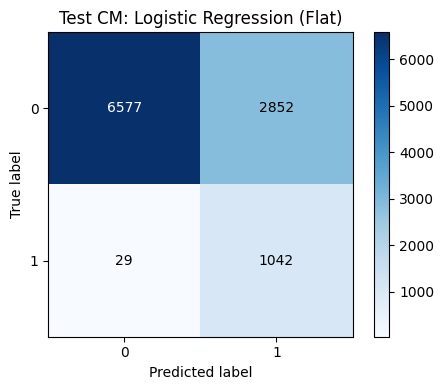

──────── KNN ────────
  Fold 01/25 - train=2680, val=1961
  Fold 02/25 - train=2666, val=1960
  Fold 03/25 - train=2686, val=1960
  Fold 04/25 - train=2698, val=1960
  Fold 05/25 - train=2666, val=1960
  Fold 06/25 - train=2694, val=1960
  Fold 07/25 - train=2710, val=1960
  Fold 08/25 - train=2678, val=1960
  Fold 09/25 - train=2676, val=1960
  Fold 10/25 - train=2696, val=1960
  Fold 11/25 - train=2702, val=1960
  Fold 12/25 - train=2702, val=1960
  Fold 13/25 - train=2690, val=1960
  Fold 14/25 - train=2690, val=1960
  Fold 15/25 - train=2632, val=1960
  Fold 16/25 - train=2738, val=1960
  Fold 17/25 - train=2694, val=1960
  Fold 18/25 - train=2714, val=1960
  Fold 19/25 - train=2690, val=1960
  Fold 20/25 - train=2672, val=1960
  Fold 21/25 - train=2720, val=1960
  Fold 22/25 - train=2708, val=1960
  Fold 23/25 - train=2692, val=1960
  Fold 24/25 - train=2724, val=1960
  Fold 25/25 - train=2660, val=1959
  [CV] Accuracy: 0.8983 +/- 0.0090  |  W-F1: 0.8007 +/- 0.0123
  Retraining on

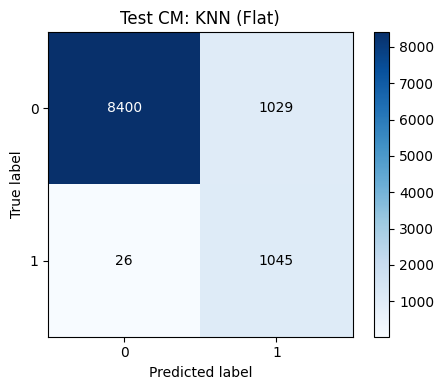

──────── SVC ────────
  Fold 01/25 - train=2670, val=1961
  Fold 02/25 - train=2714, val=1960
  Fold 03/25 - train=2706, val=1960
  Fold 04/25 - train=2690, val=1960
  Fold 05/25 - train=2684, val=1960
  Fold 06/25 - train=2690, val=1960
  Fold 07/25 - train=2694, val=1960
  Fold 08/25 - train=2724, val=1960
  Fold 09/25 - train=2684, val=1960
  Fold 10/25 - train=2720, val=1960
  Fold 11/25 - train=2672, val=1960
  Fold 12/25 - train=2708, val=1960
  Fold 13/25 - train=2688, val=1960
  Fold 14/25 - train=2678, val=1960
  Fold 15/25 - train=2686, val=1960
  Fold 16/25 - train=2708, val=1960
  Fold 17/25 - train=2674, val=1960
  Fold 18/25 - train=2710, val=1960
  Fold 19/25 - train=2702, val=1960
  Fold 20/25 - train=2710, val=1960
  Fold 21/25 - train=2688, val=1960
  Fold 22/25 - train=2698, val=1960
  Fold 23/25 - train=2736, val=1960
  Fold 24/25 - train=2686, val=1960
  Fold 25/25 - train=2714, val=1959
  [CV] Accuracy: 0.9716 +/- 0.0032  |  W-F1: 0.9173 +/- 0.0093
  Retraining on

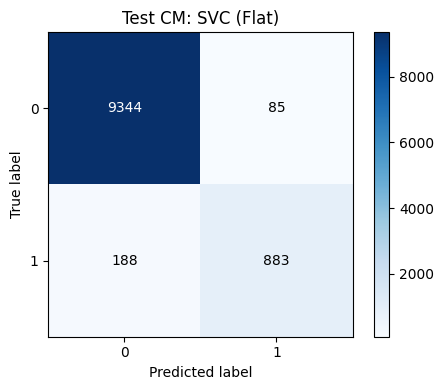

| Model (Feature)                      | Accuracy | W-Prec.  | W-Recall |   W-F1   |
|--------------------------------------+----------+----------+----------+----------+
| Logistic Regression (Flat)           | 0.7256   | 0.6316   | 0.8352   | 0.6200   |
| KNN (Flat)                           | 0.8995   | 0.7504   | 0.9333   | 0.8027   |
| SVC (Flat)                           | 0.9740   | 0.9462   | 0.9077   | 0.9259   |


In [13]:
B_FOLDS = 25
USE_OVERSAMPLING = True
SUBSAMPLE_SIZE = 1500
NUM_CLASSES = 2

folds_idx    = create_stratified_folds(y_tr, B_FOLDS, NUM_CLASSES)

pipeline_configs = [
    ('Logistic Regression', LogisticRegression,   {'lr': 0.01, 'max_iter': 100, 'C': 1.0}),
    ('KNN',                 KNeighborsClassifier, {'n_neighbors': 5, 'p': 2}),
    ('SVC',                 SVC,                  {}),
]

summary_results = []
trained_models  = {}

for model_name, ModelClass, kwargs in pipeline_configs:
    print(f"{'─'*8} {model_name} {'─'*8}")
    fold_metrics = []

    for b in range(B_FOLDS):
        
        val_idx   = folds_idx[b]
        train_idx = np.concatenate([folds_idx[i] for i in range(B_FOLDS) if i != b])

        X_batch_tr,  y_batch_tr  = Xtr_flat_sc[train_idx], y_tr[train_idx]
        X_batch_val, y_batch_val = Xtr_flat_sc[val_idx],   y_tr[val_idx]

        if SUBSAMPLE_SIZE is not None and len(X_batch_tr) > SUBSAMPLE_SIZE:
            sub_idx = np.random.choice(len(X_batch_tr), SUBSAMPLE_SIZE, replace=False)
            X_batch_tr, y_batch_tr = X_batch_tr[sub_idx], y_batch_tr[sub_idx]

        if USE_OVERSAMPLING:
            X_batch_tr, y_batch_tr = apply_smote(
                X_batch_tr, y_batch_tr, NUM_CLASSES, k_neighbors=5)

        print(f'  Fold {b+1:02d}/{B_FOLDS} - train={len(X_batch_tr)}, val={len(X_batch_val)}')

        model = ModelClass(**kwargs)
        model.fit(X_batch_tr, y_batch_tr)

        y_pred  = model.predict(X_batch_val)
        metrics = evaluate(y_batch_val, y_pred, num_classes=NUM_CLASSES)
        fold_metrics.append(metrics)

    accs = [m['accuracy']    for m in fold_metrics]
    w_f1 = [m['weighted_f1'] for m in fold_metrics]
    print(f'  [CV] Accuracy: {np.mean(accs):.4f} +/- {np.std(accs):.4f}'
          f'  |  W-F1: {np.mean(w_f1):.4f} +/- {np.std(w_f1):.4f}')

    # Re-train on the full training set for held-out test evaluation
    X_full_tr = Xtr_flat_sc.copy()
    y_full_tr = y_tr.copy()

    if SUBSAMPLE_SIZE is not None and len(X_full_tr) > SUBSAMPLE_SIZE:
        sub_idx = np.random.choice(len(X_full_tr), SUBSAMPLE_SIZE, replace=False)
        X_full_tr, y_full_tr = X_full_tr[sub_idx], y_full_tr[sub_idx]

    if USE_OVERSAMPLING:
        X_full_tr, y_full_tr = apply_smote(
            X_full_tr, y_full_tr, NUM_CLASSES, k_neighbors=5)

    print('  Retraining on full training set...')
    final_model = ModelClass(**kwargs)
    final_model.fit(X_full_tr, y_full_tr)

    y_te_pred    = final_model.predict(Xte_flat_sc)
    test_metrics = evaluate(y_te, y_te_pred, num_classes=NUM_CLASSES)

    run_key = f'{model_name} (Flat)'
    summary_results.append({
        'Model':    run_key,
        'Feature':  'Flat',
        'Accuracy': test_metrics['accuracy'],
        'W-Prec.':  test_metrics['weighted_precision'],
        'W-Recall': test_metrics['weighted_recall'],
        'W-F1':     test_metrics['weighted_f1'],
    })
    trained_models[run_key] = final_model
    plot_confusion_matrix(test_metrics['confusion_matrix'],
                          title=f'Test CM: {run_key}')

# ── Summary table ─────────────────────────────────────────────────────────────
W = 36
hdr = '| {:<{w}} | {:^8} | {:^8} | {:^8} | {:^8} |'.format(
    'Model (Feature)', 'Accuracy', 'W-Prec.', 'W-Recall', 'W-F1', w=W)
sep = '|' + '-'*(W+2) + '+----------+----------+----------+----------+'
print('' + hdr)
print(sep)
for res in summary_results:
    print('| {:<{w}} | {:.4f}   | {:.4f}   | {:.4f}   | {:.4f}   |'.format(
        res['Model'], res['Accuracy'], res['W-Prec.'],
        res['W-Recall'], res['W-F1'], w=W))